In [423]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from collections import Counter
import ipywidgets as widgets

In [424]:
DETECTOR_WIDTH = 352
DETECTOR_HEIGHT = 384
HALF_WIDTH = 352 / 2
HALF_HEIGHT = 384 / 2
cutout_radius = 30

In [425]:
import numpy as np
from scipy.ndimage import gaussian_filter

# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

## Single Electron Droplets

In [426]:
f = uproot.open("outputs/DropletTest_Singles.root")

pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

digi_edeps_map = digitize(edeps_map.T)

hits_map,_,_ = f['EntryMap'].to_numpy()

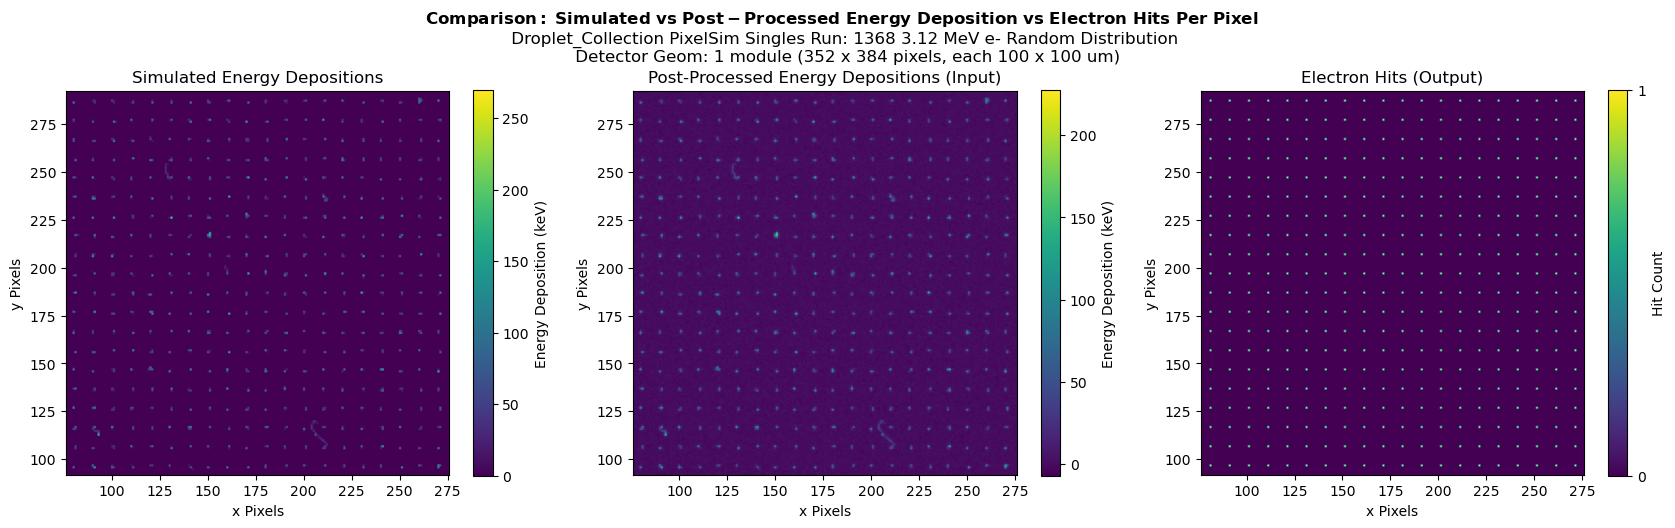

In [427]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

radius = 100

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n Droplet_Collection PixelSim Singles Run: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    cbar = ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(mid_x-radius,mid_x+radius)
    ax[i].set_ylim(mid_y-radius,mid_y+radius)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("fig/100x100_singles_droplets.png", dpi=150);
plt.show()

In [428]:
singles_data = edeps_map.T
singles_binary = singles_data > 0
singles_labeled, num_feats = label(singles_binary)
singles_slices = find_objects(singles_labeled)

cluster_1_means = []
cluster_1_stds = []
cluster_1_sizes = []
for slc in singles_slices:
    cluster_vals = singles_data[slc[0].start:slc[0].stop,slc[1].start:slc[1].stop].flatten()
    cluster_vals = cluster_vals[cluster_vals != 0]
    cluster_1_means.append(np.mean(cluster_vals))
    cluster_1_stds.append(np.std(cluster_vals))
    cluster_1_sizes.append(len(cluster_vals))

## Double Electron Droplets

In [429]:
f = uproot.open("outputs/DropletTest_Doubles.root")

pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

digi_edeps_map = digitize(edeps_map.T)

hits_map,_,_ = f['EntryMap'].to_numpy()

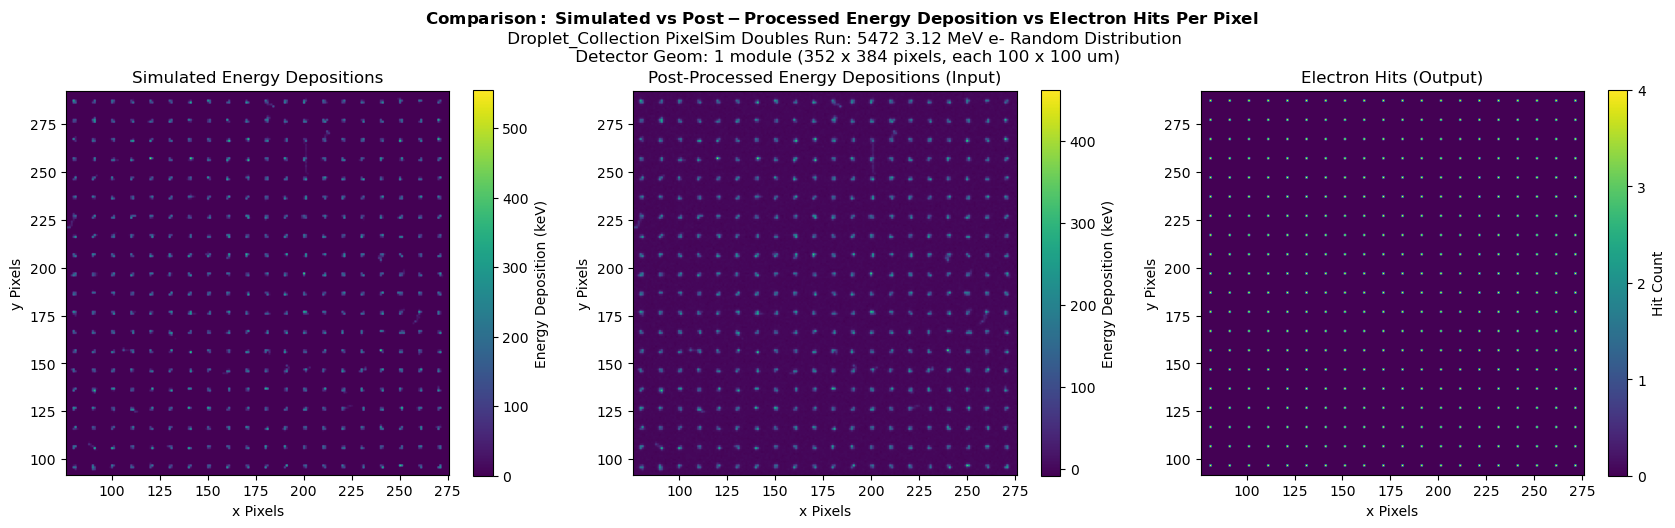

In [430]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n Droplet_Collection PixelSim Doubles Run: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    cbar = ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(mid_x-radius,mid_x+radius)
    ax[i].set_ylim(mid_y-radius,mid_y+radius)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("fig/100x100_doubles_droplets.png", dpi=150);
plt.show()

In [431]:
doubles_data = edeps_map.T
doubles_binary = doubles_data > 0
doubles_labeled, num_feats = label(doubles_binary)
doubles_slices = find_objects(doubles_labeled)

cluster_2_means = []
cluster_2_stds = []
cluster_2_sizes = []
for slc in doubles_slices:
    cluster_vals = doubles_data[slc[0].start:slc[0].stop,slc[1].start:slc[1].stop].flatten()
    cluster_vals = cluster_vals[cluster_vals != 0]
    cluster_2_means.append(np.mean(cluster_vals))
    cluster_2_stds.append(np.std(cluster_vals))
    cluster_2_sizes.append(len(cluster_vals))

## Single Electron Pairs (Adjacent)

In [432]:
f = uproot.open("outputs/DropletTest_Adjacents.root")

pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

digi_edeps_map = digitize(edeps_map.T)

hits_map,_,_ = f['EntryMap'].to_numpy()

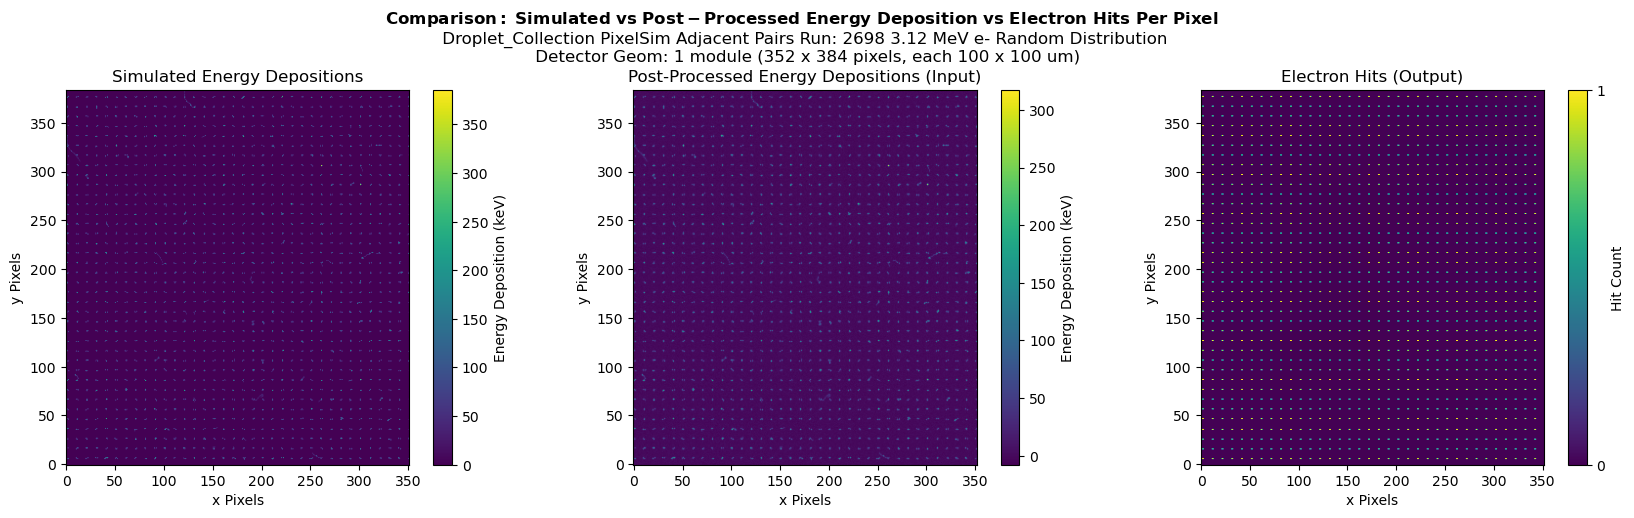

In [433]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n Droplet_Collection PixelSim Adjacent Pairs Run: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    cbar = ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    #ax[i].set_xlim(mid_x-radius,mid_x+radius)
    #ax[i].set_ylim(mid_y-radius,mid_y+radius)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("fig/100x100_adj_pair_droplets.png", dpi=150);
plt.show()

In [434]:
adj_pairs_data = edeps_map.T
adj_pairs_binary = adj_pairs_data > 0
adj_pairs_labeled, num_feats = label(adj_pairs_binary)
adj_pairs_slices = find_objects(adj_pairs_labeled)

cluster_adj_means = []
cluster_adj_stds = []
cluster_adj_sizes = []
for slc in adj_pairs_slices:
    cluster_vals = adj_pairs_data[slc[0].start:slc[0].stop,slc[1].start:slc[1].stop].flatten()
    cluster_vals = cluster_vals[cluster_vals != 0]
    cluster_adj_means.append(np.mean(cluster_vals))
    cluster_adj_stds.append(np.std(cluster_vals))
    cluster_adj_sizes.append(len(cluster_vals))

## Single Electron Pairs (Diagonal)

In [435]:
f = uproot.open("outputs/DropletTest_Diagonals.root")

pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

digi_edeps_map = digitize(edeps_map.T)

hits_map,_,_ = f['EntryMap'].to_numpy()

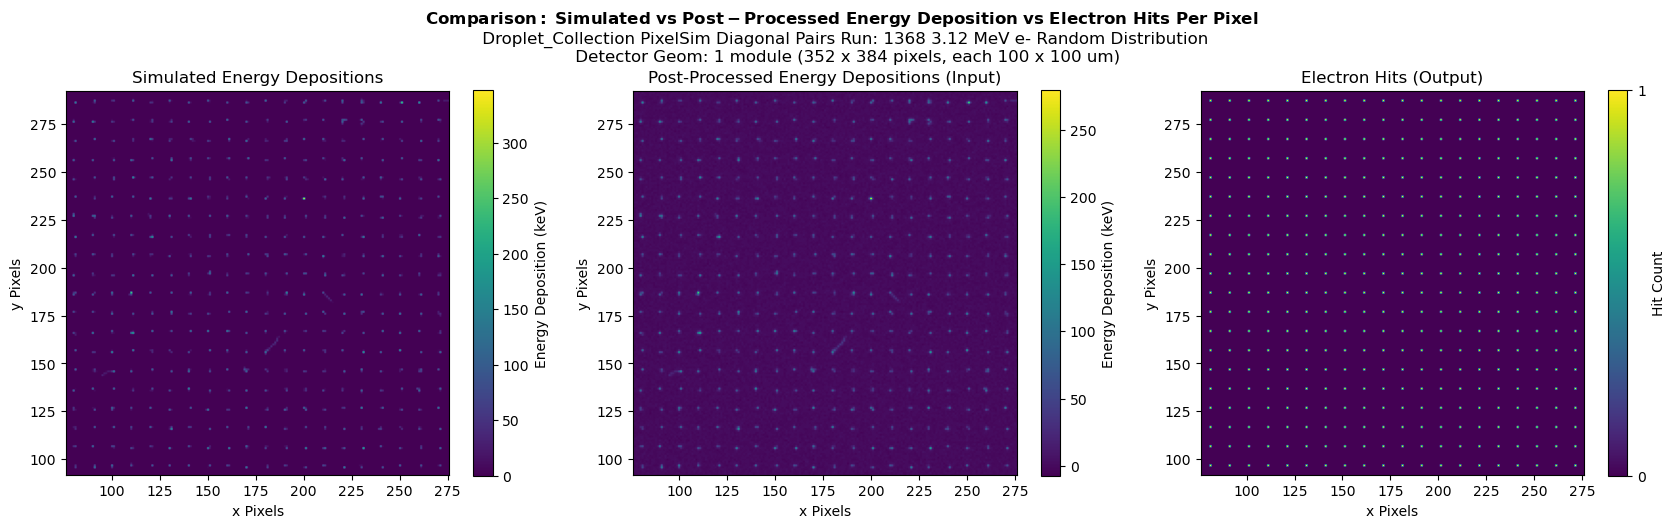

In [436]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n Droplet_Collection PixelSim Diagonal Pairs Run: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    cbar = ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(mid_x-radius,mid_x+radius)
    ax[i].set_ylim(mid_y-radius,mid_y+radius)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("fig/100x100_diag_pair_droplets.png", dpi=150);
plt.show()

In [437]:
diag_pairs_data = edeps_map.T
diag_pairs_binary = diag_pairs_data > 0
diag_pairs_labeled, num_feats = label(diag_pairs_binary)
diag_pairs_slices = find_objects(diag_pairs_labeled)

cluster_diag_means = []
cluster_diag_stds = []
cluster_diag_sizes = []
for slc in diag_pairs_slices:
    cluster_vals = diag_pairs_data[slc[0].start:slc[0].stop,slc[1].start:slc[1].stop].flatten()
    cluster_vals = cluster_vals[cluster_vals != 0]
    cluster_diag_means.append(np.mean(cluster_vals))
    cluster_diag_stds.append(np.std(cluster_vals))
    cluster_diag_sizes.append(len(cluster_vals))

## Comparisons

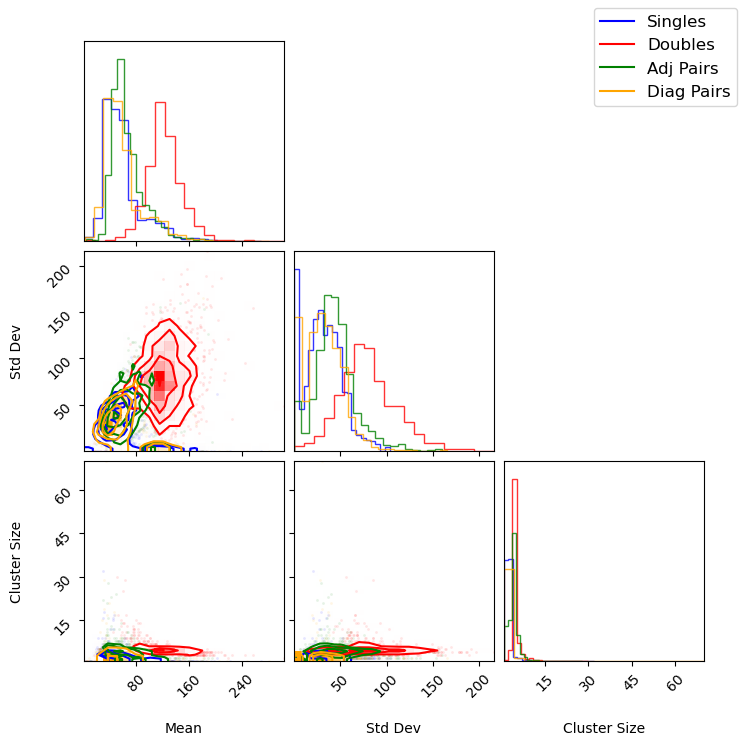

In [438]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Dataset labels and colors
dataset_labels = ["Singles", "Doubles", "Adj Pairs", "Diag Pairs"]
colors = ["blue", "red", "green", "orange"]

# Stack each dataset into shape (n_samples, 3)
singles_data = np.column_stack([cluster_1_means, cluster_1_stds, cluster_1_sizes])
doubles_data = np.column_stack([cluster_2_means, cluster_2_stds, cluster_2_sizes])
adj_data = np.column_stack([cluster_adj_means, cluster_adj_stds, cluster_adj_sizes])
diag_data = np.column_stack([cluster_diag_means, cluster_diag_stds, cluster_diag_sizes])

all_data = [singles_data, doubles_data, adj_data, diag_data]

# Plot each dataset on the same figure with a different color
fig = None
for i, dataset in enumerate(all_data):
    fig = corner.corner(
        dataset,
        labels=["Mean", "Std Dev", "Cluster Size"],
        color=colors[i],
        hist_kwargs={"density": True, "alpha": 0.8},
        fig=fig,  # pass the figure back in to overlay
    )

# Add a legend
legend_handles = [
    mlines.Line2D([], [], color=colors[i], label=dataset_labels[i])
    for i in range(len(all_data))
]
fig.legend(handles=legend_handles, fontsize=12)
plt.show()